# Swarm Data Analysis

## Datasets

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")

optimized = pd.read_csv("swarm_foraging_experiment_optimized_20260506_190123.csv")
hypothesis = pd.read_csv("swarm_foraging_experiment_hypothesized_20260506_190123.csv")

cols_to_drop = [
    "iteration", "width", "height", "n_food_clusters", 
    "food_area_percentage", "food_base_quantity", "num_agents", 
    "pheromone_decay_rate", "safety_buffer_steps", "foraging_start_threshold", 
    "pheromone_memory_weight", "pheromone_base_drop", "pheromone_follow_prob", "seed"
]

optimized = optimized.drop(columns=cols_to_drop, errors='ignore')
hypothesis = hypothesis.drop(columns=cols_to_drop, errors='ignore')

display(optimized.head())
display(hypothesis.head())

C:\Users\tasio\AppData\Local\Temp\ipykernel_32636\3037052934.py:9: DtypeWarning: Columns (0: Has Food) have mixed types. Specify dtype option on import or set low_memory=False.
  optimized = pd.read_csv("swarm_foraging_experiment_optimized_20260506_190123.csv")
C:\Users\tasio\AppData\Local\Temp\ipykernel_32636\3037052934.py:10: DtypeWarning: Columns (0: Has Food) have mixed types. Specify dtype option on import or set low_memory=False.
  hypothesis = pd.read_csv("swarm_foraging_experiment_hypothesized_20260506_190123.csv")


,RunId,Step,Foraging,Returning,Resting,Alive,Dead (Energy),Dead (Temperature),Deaths Foraging (Energy),Deaths Foraging (Temperature),...,Mean Distance to Nest,Mean Lifetime Food Collected,AgentID,Energy,Temperature,State,Distance_to_Nest,Age,Lifetime Food Collected,Has Food
0,0,0.0,46,0,0,46,0,0,0,0,...,0.0,0.0,1.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
1,0,0.0,46,0,0,46,0,0,0,0,...,0.0,0.0,2.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
2,0,0.0,46,0,0,46,0,0,0,0,...,0.0,0.0,3.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
3,0,0.0,46,0,0,46,0,0,0,0,...,0.0,0.0,4.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
4,0,0.0,46,0,0,46,0,0,0,0,...,0.0,0.0,5.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False


,RunId,Step,Foraging,Returning,Resting,Alive,Dead (Energy),Dead (Temperature),Deaths Foraging (Energy),Deaths Foraging (Temperature),...,Mean Distance to Nest,Mean Lifetime Food Collected,AgentID,Energy,Temperature,State,Distance_to_Nest,Age,Lifetime Food Collected,Has Food
0,0,0.0,50,0,0,50,0,0,0,0,...,0.0,0.0,1.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
1,0,0.0,50,0,0,50,0,0,0,0,...,0.0,0.0,2.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
2,0,0.0,50,0,0,50,0,0,0,0,...,0.0,0.0,3.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
3,0,0.0,50,0,0,50,0,0,0,0,...,0.0,0.0,4.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
4,0,0.0,50,0,0,50,0,0,0,0,...,0.0,0.0,5.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False


In [8]:
def process_swarm_data(df, name):
    print(f"--- Processing Dataset: {name} ---")
    step_keys = ["RunId", "Step"] 
    
    step_df = (
        df.drop_duplicates(step_keys)
        .sort_values(step_keys)
        .copy()
        .reset_index(drop=True)
    )
    step_df["Step"] = step_df["Step"].astype(int)

    # Final State of each Run
    run_df = step_df.groupby("RunId", as_index=False).tail(1).copy().reset_index(drop=True)
    run_df["completed_steps"] = run_df["Step"] + 1
    
    # Food ratio 
    run_df["food_collection_ratio"] = run_df["Total Food Collected"] / (
        run_df["Total Food Collected"] + run_df["Remaining Food (Units)"].clip(lower=1.0)
    )

    rows_per_run = df.groupby("RunId").size().rename("rows")
    steps_per_run = step_df.groupby("RunId")["Step"].nunique().rename("unique_steps")
    
    cols_to_keep = [
        "RunId", "completed_steps", "Alive", "Dead (Energy)", "Dead (Temperature)",
        "Total Food Collected", "Remaining Food (Units)", "Resource Retrieval Rate",
        "Load Gini", "Cumulative Thermal Load", "Shannon Entropy", "Thermal Efficiency",
        "Mean Agent Energy", "Mean Agent Temperature", "Mean Distance to Nest",
        "Mean Lifetime Food Collected"
    ]
    
    run_summary = (
        run_df[[c for c in cols_to_keep if c in run_df.columns]]
        .merge(rows_per_run, on="RunId")
        .merge(steps_per_run, on="RunId")
        .sort_values("RunId")
        .reset_index(drop=True)
    )

    print(f"- Runs represented: {run_summary['RunId'].nunique():,}")
    print(f"- Mean completed steps: {run_summary['completed_steps'].mean():,.2f}")
    print()

    stats_cols = ["completed_steps", "Total Food Collected", "Resource Retrieval Rate", "Load Gini", "Thermal Efficiency", "Shannon Entropy"]
    summary_stats = run_summary[[c for c in stats_cols if c in run_summary.columns]].describe().T
    
    display(summary_stats)
    return run_summary, summary_stats

optimized_summary, optimized_stats = process_swarm_data(optimized, "Optimized")
hypothesis_summary, hypothesis_stats = process_swarm_data(hypothesis, "Hypothesis")

--- Processing Dataset: Optimized ---
- Runs represented: 30
- Mean completed steps: 6,682.70



,count,mean,std,min,25%,50%,75%,max
completed_steps,30.0,6682.700000,2936.829972,1949.000000,3924.750000,6304.500000,9433.500000,11915.000000
Total Food Collected,30.0,1855.000000,1052.296929,130.000000,1062.000000,1658.500000,2517.250000,4634.000000
Resource Retrieval Rate,30.0,0.286581,0.160311,0.066735,0.196436,0.253888,0.340731,0.970207
Load Gini,30.0,0.254525,0.104943,0.056661,0.192485,0.228835,0.309970,0.517391
Thermal Efficiency,30.0,0.005448,0.002346,0.000922,0.004449,0.004999,0.005990,0.012807
Shannon Entropy,30.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


--- Processing Dataset: Hypothesis ---
- Runs represented: 30
- Mean completed steps: 1,120.17



,count,mean,std,min,25%,50%,75%,max
completed_steps,30.0,1120.166667,510.228690,424.000000,752.250000,1044.000000,1464.500000,2512.000000
Total Food Collected,30.0,399.866667,339.556073,15.000000,138.000000,301.500000,595.250000,1202.000000
Resource Retrieval Rate,30.0,0.308999,0.216915,0.031505,0.148321,0.276732,0.470742,0.890977
Load Gini,30.0,0.317298,0.190921,0.074852,0.175355,0.240191,0.429444,0.730588
Thermal Efficiency,30.0,0.003395,0.002615,0.000213,0.001466,0.002717,0.005035,0.009902
Shannon Entropy,30.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Survival Analysis

--- Survival Analysis: Optimized ---
- Agents observed (total pool): 1,380
- Mean lifetime: 2,510.5 steps
- Median lifetime: 2,075.5 steps
- Min / max lifetime: 273 / 11,914 steps
- Kaplan-Meier median survival time: 2,076 steps
- Death causes by model counters: 100.0% energy, 0.0% temperature



,last_state,agents,percent
0,RESTING,467,33.840580
1,RETURNING,459,33.260870
2,FORAGING,454,32.898551




--- Survival Analysis: Hypothesis ---
- Agents observed (total pool): 1,500
- Mean lifetime: 607.5 steps
- Median lifetime: 516.0 steps
- Min / max lifetime: 219 / 2,511 steps
- Kaplan-Meier median survival time: 516 steps
- Death causes by model counters: 100.0% energy, 0.0% temperature



,last_state,agents,percent
0,RETURNING,642,42.800000
1,FORAGING,436,29.066667
2,RESTING,422,28.133333


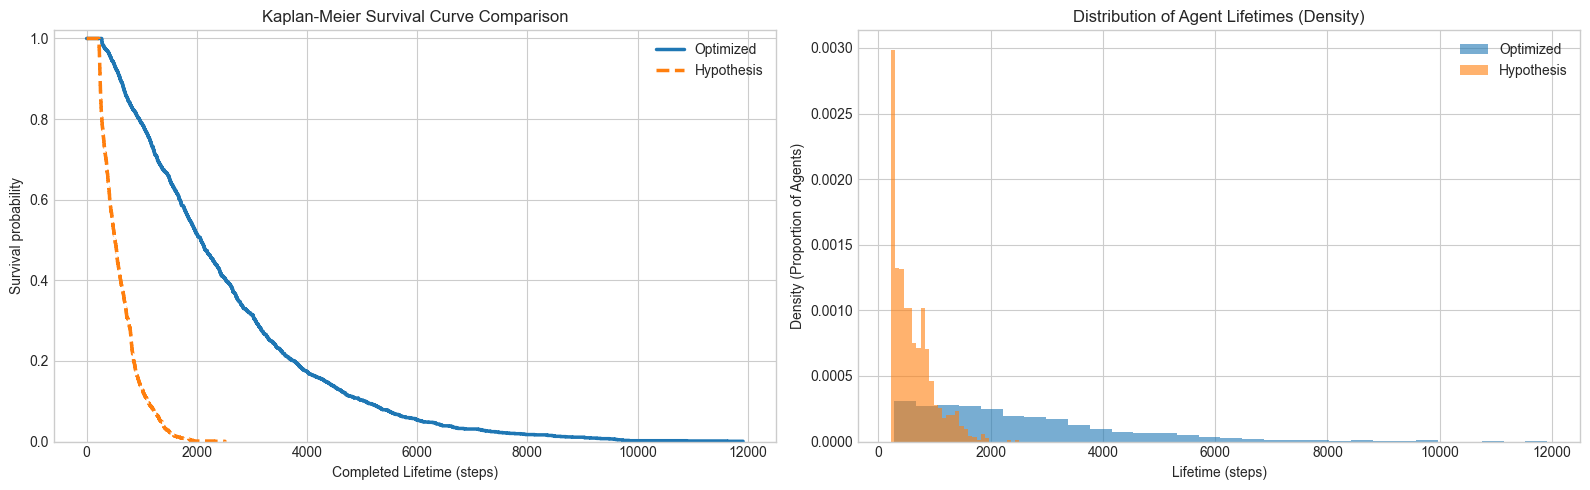

In [9]:
def analyze_agent_survival(df, dataset_name):
    print(f"--- Survival Analysis: {dataset_name} ---")
    
    agent_last_index = df.groupby(["RunId", "AgentID"])['Step'].idxmax()
    last_agent_rows = df.loc[agent_last_index].copy().reset_index(drop=True)
    last_agent_rows["lifetime_steps"] = last_agent_rows["Step"].astype(int) + 1

    agent_lifetimes = last_agent_rows[["RunId", "AgentID", "lifetime_steps", "State", "Temperature", "Energy", "Has Food", "Distance_to_Nest"]].copy()

    life_counts = agent_lifetimes["lifetime_steps"].value_counts().sort_index()
    km_times = []
    km_survival = []
    n_at_risk = int(agent_lifetimes.shape[0])
    survival_probability = 1.0
    
    for time_step, event_count in life_counts.items():
        if n_at_risk <= 0:
            break
        survival_probability *= 1.0 - (event_count / n_at_risk)
        km_times.append(int(time_step))
        km_survival.append(float(survival_probability))
        n_at_risk -= int(event_count)

    km_curve = pd.DataFrame({"time": km_times, "survival_probability": km_survival})
    median_survival = next((time for time, survival in zip(km_times, km_survival) if survival <= 0.5), None)

    cause_counts = last_agent_rows["State"].value_counts().rename_axis("last_state").reset_index(name="agents")
    state_percent = cause_counts.copy()
    state_percent["percent"] = 100.0 * state_percent["agents"] / state_percent["agents"].sum()

    run_df = df.groupby("RunId").tail(1)
    final_death_summary = run_df[["Dead (Energy)", "Dead (Temperature)"]].sum()
    total_deaths = float(final_death_summary.sum())
    energy_share = 100.0 * final_death_summary["Dead (Energy)"] / max(total_deaths, 1.0)
    temp_share = 100.0 * final_death_summary["Dead (Temperature)"] / max(total_deaths, 1.0)

    print(f"- Agents observed (total pool): {len(agent_lifetimes):,}")
    print(f"- Mean lifetime: {agent_lifetimes['lifetime_steps'].mean():,.1f} steps")
    print(f"- Median lifetime: {agent_lifetimes['lifetime_steps'].median():,.1f} steps")
    print(f"- Min / max lifetime: {agent_lifetimes['lifetime_steps'].min():,} / {agent_lifetimes['lifetime_steps'].max():,} steps")
    
    if median_survival is not None:
        print(f"- Kaplan-Meier median survival time: {median_survival:,} steps")
    else:
        print("- Kaplan-Meier median survival time was not reached.")
        
    print(f"- Death causes by model counters: {energy_share:.1f}% energy, {temp_share:.1f}% temperature")
    print()
    display(state_percent)
    print("\n" + "="*50 + "\n")
    
    return km_curve, agent_lifetimes

# Run the analysis on both datasets
km_opt, lifetimes_opt = analyze_agent_survival(optimized, "Optimized")
km_hyp, lifetimes_hyp = analyze_agent_survival(hypothesis, "Hypothesis")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Kaplan-Meier Curve Comparison
ax1.step([0, *km_opt['time']], [1.0, *km_opt['survival_probability']], where="post", linewidth=2.5, label="Optimized")
ax1.step([0, *km_hyp['time']], [1.0, *km_hyp['survival_probability']], where="post", linewidth=2.5, label="Hypothesis", linestyle="--")
ax1.set_title("Kaplan-Meier Survival Curve Comparison")
ax1.set_xlabel("Completed Lifetime (steps)")
ax1.set_ylabel("Survival probability")
ax1.set_ylim(0, 1.02)
ax1.legend()

# Lifetime Distribution Histogram Comparison
ax2.hist(lifetimes_opt["lifetime_steps"], bins=30, alpha=0.6, label="Optimized", density=True, color="#1f77b4")
ax2.hist(lifetimes_hyp["lifetime_steps"], bins=30, alpha=0.6, label="Hypothesis", density=True, color="#ff7f0e")
ax2.set_title("Distribution of Agent Lifetimes (Density)")
ax2.set_xlabel("Lifetime (steps)")
ax2.set_ylabel("Density (Proportion of Agents)")
ax2.legend()

plt.tight_layout()
plt.show()

## Mission Progression and System Dynamics

--- Mission Progression: Optimized ---
- Avg survival ratio: 0.376
- Avg resource retrieval rate: 0.706
- Avg Shannon entropy: 0.802
- Avg thermal efficiency: 0.02125



,phase,survival_ratio,food_collection_ratio,resource_retrieval_rate,mean_agent_energy,mean_agent_temperature,mean_distance_to_nest,shannon_entropy,thermal_efficiency,load_gini,share_foraging,share_returning,share_resting,share_has_food
0,0-20%,0.917166,0.089029,1.545291,836.812799,32.289456,5.900075,0.933806,0.078907,0.145590,0.778533,0.187403,0.034064,0.184589
1,20-40%,0.568449,0.163852,0.759001,745.835406,33.446943,7.284444,0.973649,0.009337,0.163553,0.832573,0.139227,0.028200,0.132379
2,40-60%,0.257960,0.190940,0.523922,723.107652,33.714072,7.611338,0.961168,0.006509,0.207701,0.839963,0.132597,0.027439,0.124470
3,60-80%,0.097487,0.200428,0.391507,711.520547,33.844012,7.569520,0.783370,0.005843,0.232095,0.847573,0.124944,0.027483,0.118179
4,80-100%,0.037116,0.203454,0.308644,676.011092,34.185634,7.705287,0.356020,0.005647,0.242027,0.850623,0.121694,0.026935,0.108837




--- Mission Progression: Hypothesis ---
- Avg survival ratio: 0.542
- Avg resource retrieval rate: 0.902
- Avg Shannon entropy: 0.716
- Avg thermal efficiency: 0.03938



,phase,survival_ratio,food_collection_ratio,resource_retrieval_rate,mean_agent_energy,mean_agent_temperature,mean_distance_to_nest,shannon_entropy,thermal_efficiency,load_gini,share_foraging,share_returning,share_resting,share_has_food
0,0-20%,0.996972,0.021951,1.983472,842.478046,31.721432,2.410988,0.730651,0.169014,0.269809,0.841087,0.129648,0.029265,0.129498
1,20-40%,0.864506,0.039404,0.947572,643.240959,33.813289,2.264106,0.743792,0.012383,0.230868,0.908484,0.070551,0.020964,0.065241
2,40-60%,0.553342,0.047468,0.672210,555.995659,35.077534,2.087524,0.776756,0.006342,0.243785,0.922507,0.059554,0.017939,0.049018
3,60-80%,0.239649,0.050493,0.507634,468.365801,36.523421,1.931256,0.802232,0.004686,0.259192,0.931511,0.050566,0.017923,0.034965
4,80-100%,0.057077,0.051065,0.398242,370.047580,37.010370,1.765031,0.525954,0.004216,0.264338,0.937350,0.040852,0.017339,0.014368


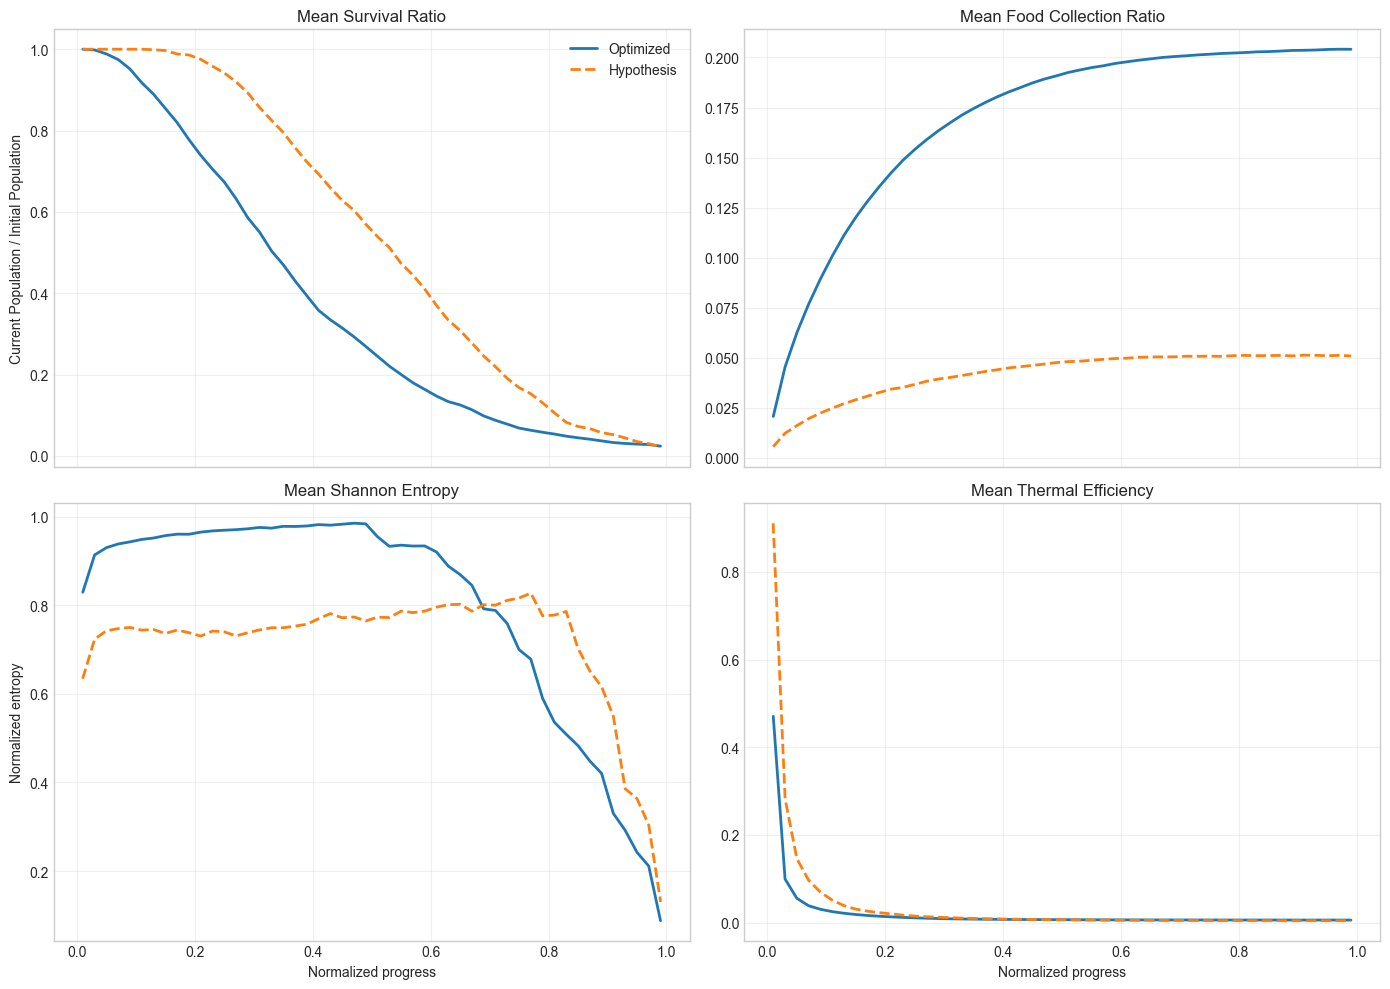

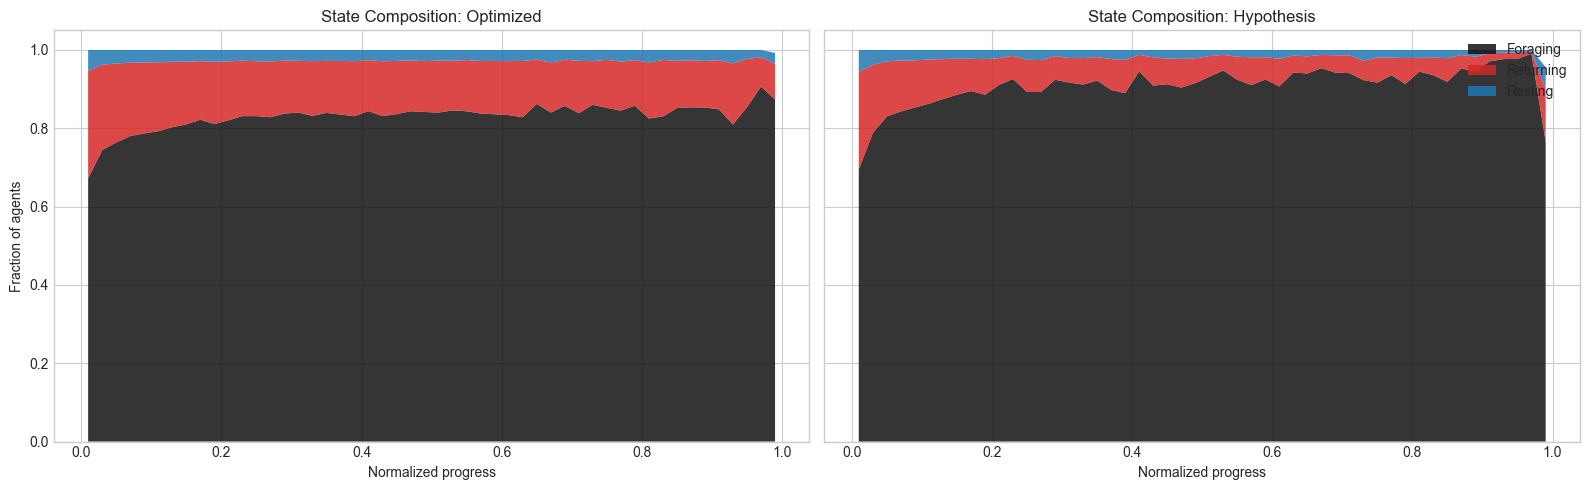

In [10]:
def process_mission_progression(df, dataset_name):
    print(f"--- Mission Progression: {dataset_name} ---")
    
    # Work on a copy to avoid SettingWithCopy warnings
    df = df.copy()
    
    # State identification
    df["is_foraging"] = (df["State"] == "FORAGING").astype(int)
    df["is_returning"] = (df["State"] == "RETURNING").astype(int)
    df["is_resting"] = (df["State"] == "RESTING").astype(int)
    df["has_food_int"] = df["Has Food"].fillna(False).astype(bool).astype(int)

    # 1. Step-level aggregations
    step_summary = (
        df.groupby(["RunId", "Step"], as_index=False)
        .agg(
            num_agents=("AgentID", "size"),
            alive=("Alive", "first"),
            total_food_collected=("Total Food Collected", "first"),
            remaining_food_units=("Remaining Food (Units)", "first"),
            resource_retrieval_rate=("Resource Retrieval Rate", "first"),
            load_gini=("Load Gini", "first"),
            cumulative_thermal_load=("Cumulative Thermal Load", "first"),
            shannon_entropy=("Shannon Entropy", "first"),
            thermal_efficiency=("Thermal Efficiency", "first"),
            mean_agent_energy=("Energy", "mean"),
            mean_agent_temperature=("Temperature", "mean"),
            mean_distance_to_nest=("Distance_to_Nest", "mean"),
            mean_lifetime_food_collected=("Lifetime Food Collected", "mean"),
            share_foraging=("is_foraging", "mean"),
            share_returning=("is_returning", "mean"),
            share_resting=("is_resting", "mean"),
            share_has_food=("has_food_int", "mean"),
        )
        .sort_values(["RunId", "Step"])
        .reset_index(drop=True)
    )
    
    # 2. Key Ratios (FIXED)
    # Anchor the denominator to the maximum (initial) alive count for each individual run
    initial_population = step_summary.groupby("RunId")["alive"].transform("max")
    step_summary["survival_ratio"] = step_summary["alive"] / initial_population
    
    step_summary["food_collection_ratio"] = step_summary["total_food_collected"] / (
        step_summary["total_food_collected"] + step_summary["remaining_food_units"].clip(lower=1.0)
    )
    
    # 3. Normalized Progress (0 to 1)
    step_summary["normalized_progress"] = step_summary["Step"] / step_summary.groupby("RunId")["Step"].transform("max")
    
    # 4. Coarse Phases (Quintiles)
    step_summary["phase"] = pd.cut(
        step_summary["normalized_progress"],
        bins=np.linspace(0.0, 1.0, 6),
        labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
        include_lowest=True,
    )

    phase_means = (
        step_summary.groupby("phase", observed=False)
        .agg(
            survival_ratio=("survival_ratio", "mean"),
            food_collection_ratio=("food_collection_ratio", "mean"),
            resource_retrieval_rate=("resource_retrieval_rate", "mean"),
            mean_agent_energy=("mean_agent_energy", "mean"),
            mean_agent_temperature=("mean_agent_temperature", "mean"),
            mean_distance_to_nest=("mean_distance_to_nest", "mean"),
            shannon_entropy=("shannon_entropy", "mean"),
            thermal_efficiency=("thermal_efficiency", "mean"),
            load_gini=("load_gini", "mean"),
            share_foraging=("share_foraging", "mean"),
            share_returning=("share_returning", "mean"),
            share_resting=("share_resting", "mean"),
            share_has_food=("share_has_food", "mean"),
        )
        .reset_index()
    )

    # 5. Granular Curves (50 bins for plotting)
    progress_bins = np.linspace(0.0, 1.0, 51)
    step_summary["progress_bin"] = pd.cut(step_summary["normalized_progress"], bins=progress_bins, labels=False, include_lowest=True)
    
    progress_curves = (
        step_summary.dropna(subset=["progress_bin"])
        .groupby("progress_bin", observed=True)
        .agg(
            progress_center=("normalized_progress", "mean"),
            survival_ratio=("survival_ratio", "mean"),
            food_collection_ratio=("food_collection_ratio", "mean"),
            resource_retrieval_rate=("resource_retrieval_rate", "mean"),
            shannon_entropy=("shannon_entropy", "mean"),
            thermal_efficiency=("thermal_efficiency", "mean"),
            share_foraging=("share_foraging", "mean"),
            share_returning=("share_returning", "mean"),
            share_resting=("share_resting", "mean"),
        )
        .reset_index(drop=True)
    )

    # Summaries
    print(f"- Avg survival ratio: {step_summary['survival_ratio'].mean():.3f}")
    print(f"- Avg resource retrieval rate: {step_summary['resource_retrieval_rate'].mean():.3f}")
    print(f"- Avg Shannon entropy: {step_summary['shannon_entropy'].mean():.3f}")
    print(f"- Avg thermal efficiency: {step_summary['thermal_efficiency'].mean():.5f}")
    print()
    display(phase_means)
    print("\n" + "="*50 + "\n")
    
    return phase_means, progress_curves

# Execute processing
phase_opt, prog_opt = process_mission_progression(optimized, "Optimized")
phase_hyp, prog_hyp = process_mission_progression(hypothesis, "Hypothesis")

# --- PLOTTING ---

# 1. 2x2 Line Charts (Overlaid)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

# Survival Ratio
axes[0, 0].plot(prog_opt["progress_center"], prog_opt["survival_ratio"], color="#1f77b4", linewidth=2, label="Optimized")
axes[0, 0].plot(prog_hyp["progress_center"], prog_hyp["survival_ratio"], color="#ff7f0e", linewidth=2, linestyle="--", label="Hypothesis")
axes[0, 0].set_title("Mean Survival Ratio")
axes[0, 0].set_ylabel("Current Population / Initial Population")
axes[0, 0].legend()

# Food Collection Ratio
axes[0, 1].plot(prog_opt["progress_center"], prog_opt["food_collection_ratio"], color="#1f77b4", linewidth=2)
axes[0, 1].plot(prog_hyp["progress_center"], prog_hyp["food_collection_ratio"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[0, 1].set_title("Mean Food Collection Ratio")

# Shannon Entropy
axes[1, 0].plot(prog_opt["progress_center"], prog_opt["shannon_entropy"], color="#1f77b4", linewidth=2)
axes[1, 0].plot(prog_hyp["progress_center"], prog_hyp["shannon_entropy"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[1, 0].set_title("Mean Shannon Entropy")
axes[1, 0].set_xlabel("Normalized progress")
axes[1, 0].set_ylabel("Normalized entropy")

# Thermal Efficiency
axes[1, 1].plot(prog_opt["progress_center"], prog_opt["thermal_efficiency"], color="#1f77b4", linewidth=2)
axes[1, 1].plot(prog_hyp["progress_center"], prog_hyp["thermal_efficiency"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[1, 1].set_title("Mean Thermal Efficiency")
axes[1, 1].set_xlabel("Normalized progress")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. State Composition Stackplots (Side-by-side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

labels = ["Foraging", "Returning", "Resting"]
colors = ["#111111", "#d62728", "#1f77b4"]

# Optimized Stack
ax1.stackplot(
    prog_opt["progress_center"],
    prog_opt["share_foraging"], prog_opt["share_returning"], prog_opt["share_resting"],
    labels=labels, colors=colors, alpha=0.85
)
ax1.set_title("State Composition: Optimized")
ax1.set_xlabel("Normalized progress")
ax1.set_ylabel("Fraction of agents")

# Hypothesis Stack
ax2.stackplot(
    prog_hyp["progress_center"],
    prog_hyp["share_foraging"], prog_hyp["share_returning"], prog_hyp["share_resting"],
    labels=labels, colors=colors, alpha=0.85
)
ax2.set_title("State Composition: Hypothesis")
ax2.set_xlabel("Normalized progress")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 4. Energy, Heat, and Fairness


--- Energy, Heat, and Fairness: Optimized ---
- Mean agent energy at 0-20%: 836.81
- Mean agent energy at 80-100%: 676.01
- Mean temperature at 0-20%: 32.29
- Mean temperature at 80-100%: 34.19
- Load Gini at 0-20%: 0.146
- Load Gini at 80-100%: 0.242

Final Run State Summary (Cleaned):


,count,mean,std,min,25%,50%,75%,max
completed_steps,30.0,6681.700000,2936.829972,1948.000000,3923.750000,6303.500000,9432.50000,11914.000000
final_total_food_collected,30.0,1855.000000,1052.296929,130.000000,1062.000000,1658.500000,2517.25000,4634.000000
final_mean_temperature,30.0,36.065000,2.264195,31.800000,34.412500,35.875000,38.33750,40.400000
final_load_gini,30.0,0.254525,0.104943,0.056661,0.192485,0.228835,0.30997,0.517391
final_thermal_efficiency,30.0,0.005448,0.002346,0.000922,0.004449,0.004999,0.00599,0.012807



--- Energy, Heat, and Fairness: Hypothesis ---
- Mean agent energy at 0-20%: 842.48
- Mean agent energy at 80-100%: 370.05
- Mean temperature at 0-20%: 31.72
- Mean temperature at 80-100%: 37.01
- Load Gini at 0-20%: 0.270
- Load Gini at 80-100%: 0.264

Final Run State Summary (Cleaned):


,count,mean,std,min,25%,50%,75%,max
completed_steps,30.0,1119.166667,510.228690,423.000000,751.250000,1043.000000,1463.500000,2511.000000
final_total_food_collected,30.0,399.866667,339.556073,15.000000,138.000000,301.500000,595.250000,1202.000000
final_mean_temperature,30.0,38.878333,3.401690,34.700000,36.600000,39.250000,39.962500,50.250000
final_load_gini,30.0,0.317298,0.190921,0.074852,0.175355,0.240191,0.429444,0.730588
final_thermal_efficiency,30.0,0.003395,0.002615,0.000213,0.001466,0.002717,0.005035,0.009902


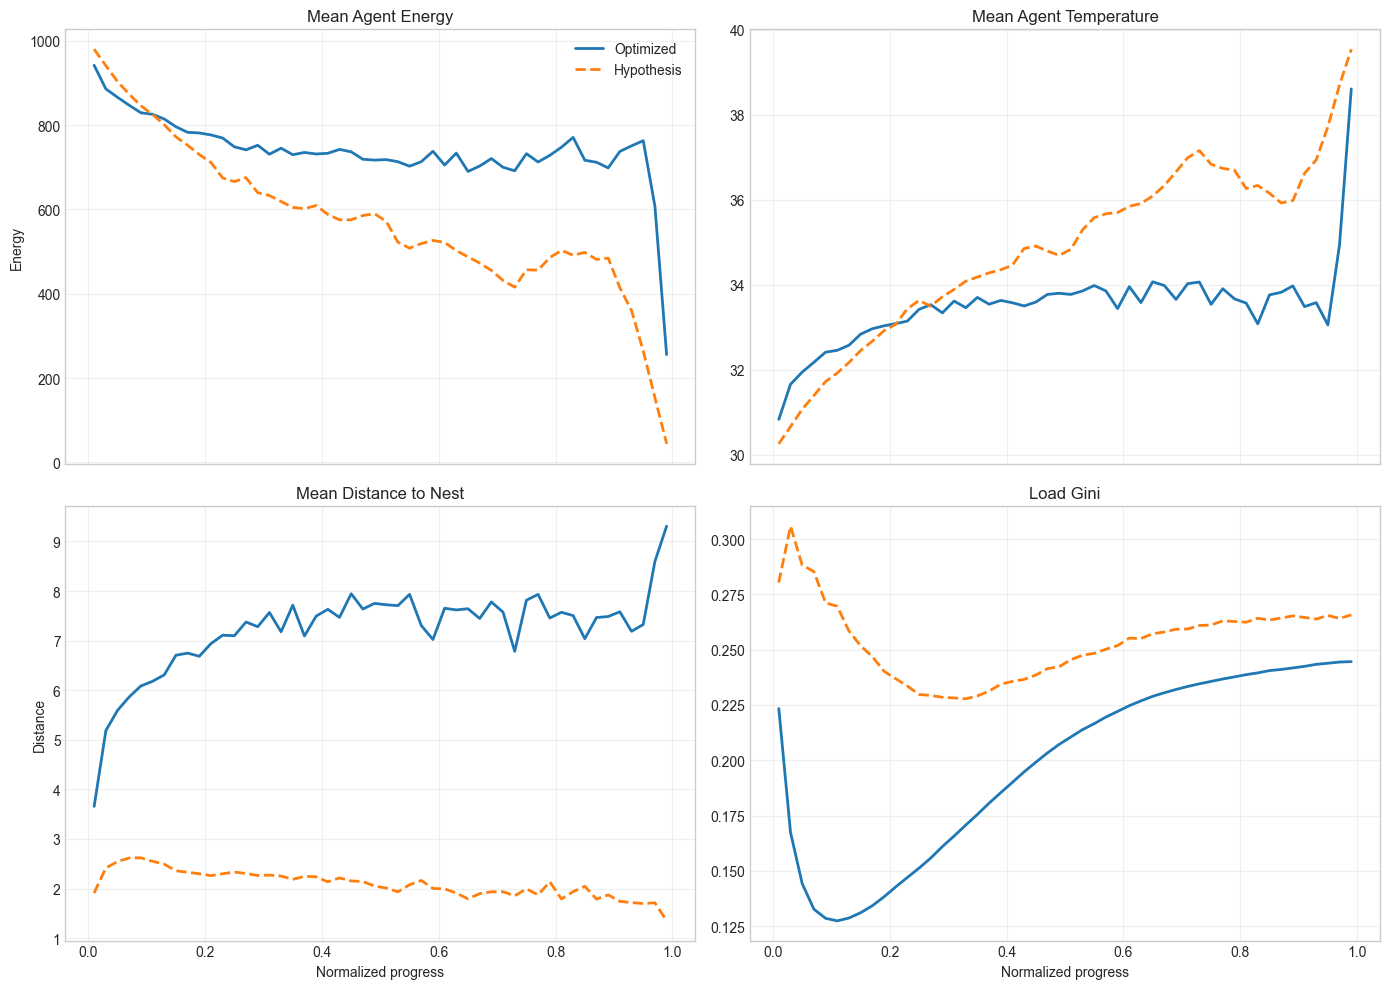

In [13]:
def process_energy_heat_fairness(df, dataset_name):
    print(f"\n--- Energy, Heat, and Fairness: {dataset_name} ---")
    
    # 1. Step-level aggregations
    step_summary = (
        df.groupby(["RunId", "Step"], as_index=False)
        .agg(
            total_food_collected=("Total Food Collected", "first"),
            mean_agent_energy=("Energy", "mean"),
            mean_agent_temperature=("Temperature", "mean"),
            mean_distance_to_nest=("Distance_to_Nest", "mean"),
            load_gini=("Load Gini", "first"),
            thermal_efficiency=("Thermal Efficiency", "first"),
        )
        .sort_values(["RunId", "Step"])
        .reset_index(drop=True)
    )
    
    # 2. Normalized Progress and Bins
    step_summary["normalized_progress"] = step_summary["Step"] / step_summary.groupby("RunId")["Step"].transform("max")
    
    step_summary["phase"] = pd.cut(
        step_summary["normalized_progress"],
        bins=np.linspace(0.0, 1.0, 6),
        labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
        include_lowest=True,
    )
    
    progress_bins = np.linspace(0.0, 1.0, 51)
    step_summary["progress_bin"] = pd.cut(step_summary["normalized_progress"], bins=progress_bins, labels=False, include_lowest=True)

    # 3. Phase Means Calculation
    phase_means = (
        step_summary.groupby("phase", observed=False)
        .agg(
            mean_agent_energy=("mean_agent_energy", "mean"),
            mean_agent_temperature=("mean_agent_temperature", "mean"),
            load_gini=("load_gini", "mean")
        )
        .reset_index()
    )

    # Print Summary for this dataset
    print(f"- Mean agent energy at 0-20%: {phase_means.loc[phase_means['phase'] == '0-20%', 'mean_agent_energy'].iloc[0]:.2f}")
    print(f"- Mean agent energy at 80-100%: {phase_means.loc[phase_means['phase'] == '80-100%', 'mean_agent_energy'].iloc[0]:.2f}")
    print(f"- Mean temperature at 0-20%: {phase_means.loc[phase_means['phase'] == '0-20%', 'mean_agent_temperature'].iloc[0]:.2f}")
    print(f"- Mean temperature at 80-100%: {phase_means.loc[phase_means['phase'] == '80-100%', 'mean_agent_temperature'].iloc[0]:.2f}")
    print(f"- Load Gini at 0-20%: {phase_means.loc[phase_means['phase'] == '0-20%', 'load_gini'].iloc[0]:.3f}")
    print(f"- Load Gini at 80-100%: {phase_means.loc[phase_means['phase'] == '80-100%', 'load_gini'].iloc[0]:.3f}")

    # 4. Progress Curves
    energy_curves = (
        step_summary.dropna(subset=["progress_bin"])
        .groupby("progress_bin", observed=True)
        .agg(
            progress_center=("normalized_progress", "mean"),
            mean_agent_energy=("mean_agent_energy", "mean"),
            mean_agent_temperature=("mean_agent_temperature", "mean"),
            mean_distance_to_nest=("mean_distance_to_nest", "mean"),
            load_gini=("load_gini", "mean"),
            thermal_efficiency=("thermal_efficiency", "mean"),
        )
        .reset_index(drop=True)
    )

    # 5. Run-level Summary (CLEANED)
    energy_temperature_run_summary = (
        step_summary.groupby("RunId", as_index=False)
        .agg(
            completed_steps=("Step", "max"),
            final_total_food_collected=("total_food_collected", "last"),
            final_mean_temperature=("mean_agent_temperature", "last"),
            final_load_gini=("load_gini", "last"),
            final_thermal_efficiency=("thermal_efficiency", "last"),
        )
    )
    
    print("\nFinal Run State Summary (Cleaned):")
    # We drop RunId here so it doesn't get calculated in the descriptive statistics
    display(energy_temperature_run_summary.drop(columns=["RunId"]).describe().T)
    
    return energy_curves

# Execute processing for both datasets
curves_opt = process_energy_heat_fairness(optimized, "Optimized")
curves_hyp = process_energy_heat_fairness(hypothesis, "Hypothesis")

# --- PLOTTING ---

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

# Mean Agent Energy
axes[0, 0].plot(curves_opt["progress_center"], curves_opt["mean_agent_energy"], color="#1f77b4", linewidth=2, label="Optimized")
axes[0, 0].plot(curves_hyp["progress_center"], curves_hyp["mean_agent_energy"], color="#ff7f0e", linewidth=2, linestyle="--", label="Hypothesis")
axes[0, 0].set_title("Mean Agent Energy")
axes[0, 0].set_ylabel("Energy")
axes[0, 0].legend()

# Mean Agent Temperature
axes[0, 1].plot(curves_opt["progress_center"], curves_opt["mean_agent_temperature"], color="#1f77b4", linewidth=2)
axes[0, 1].plot(curves_hyp["progress_center"], curves_hyp["mean_agent_temperature"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[0, 1].set_title("Mean Agent Temperature")

# Mean Distance to Nest
axes[1, 0].plot(curves_opt["progress_center"], curves_opt["mean_distance_to_nest"], color="#1f77b4", linewidth=2)
axes[1, 0].plot(curves_hyp["progress_center"], curves_hyp["mean_distance_to_nest"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[1, 0].set_title("Mean Distance to Nest")
axes[1, 0].set_xlabel("Normalized progress")
axes[1, 0].set_ylabel("Distance")

# Load Gini
axes[1, 1].plot(curves_opt["progress_center"], curves_opt["load_gini"], color="#1f77b4", linewidth=2)
axes[1, 1].plot(curves_hyp["progress_center"], curves_hyp["load_gini"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[1, 1].set_title("Load Gini")
axes[1, 1].set_xlabel("Normalized progress")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()